In [1]:
import os
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('bmh')

PYTHON_PATH = '/home/andreas/mambaforge/envs/symdel/bin/python'
WORKER_SCRIPT = 'tmp/symscan_ncpu_worker.py'
N_SEQUENCE = 1_000_000
MAX_DISTANCE = 2
DISTANCE_TYPE = 'levenshtein'
N_REPS = 1

# machine has 8 P-cores (x2 logical cores with hyperthreading) and 16 E cores
# use only single P cores for cleaner scaling analysis
MAX_NCPU = os.cpu_count()
p_core_list = '0,2,4,6,8,10,12,14'
ncpus = np.arange(1, 9, 1)

In [2]:
!mkdir -p tmp

In [3]:
%%writefile tmp/symscan_ncpu_worker.py
import sys
import time
import pandas as pd

import symscan


def main():
    n_sequence, max_distance, distance_type = sys.argv[1:5]
    n_sequence = int(n_sequence)
    max_distance = int(max_distance)

    N_FILES=1
    seqs = []
    for i in range(1,N_FILES+1):
        seqs += pd.read_csv(f'../data/emerson{i}.zip', compression='zip', header=0)['cdr3'].to_list()
    seqs = seqs[:n_sequence]

    t0 = time.perf_counter()
    symscan.get_neighbors_within(seqs, max_distance=max_distance, distance_type=distance_type)
    print(time.perf_counter() - t0)


if __name__ == '__main__':
    main()

Overwriting tmp/symscan_ncpu_worker.py


In [4]:
def measure_runtime_seconds(n_cpu, n_sequence=N_SEQUENCE, max_distance=MAX_DISTANCE, distance_type=DISTANCE_TYPE):
    cmd = ['taskset', '-c', p_core_list, 
           PYTHON_PATH, WORKER_SCRIPT, str(n_sequence), str(max_distance), distance_type]
    env = os.environ | {'RAYON_NUM_THREADS': str(n_cpu)}
    result = subprocess.run(cmd, capture_output=True, text=True, env=env)
    if result.returncode != 0:
        raise RuntimeError(result.stderr)
    return float(result.stdout)


In [5]:
rows = []
for rep in range(N_REPS):
    for n_cpu in ncpus:
        runtime_s = measure_runtime_seconds(n_cpu)
        rows.append({'algorithm': 'symscan', 'n_cpu': int(n_cpu), 'n_sequence': N_SEQUENCE,
                      'distance': MAX_DISTANCE, 'measure': DISTANCE_TYPE,
                      'runtime_s': runtime_s})
        print(n_cpu, rep, runtime_s)

ncpu_df = pd.DataFrame(rows)
ncpu_df.to_csv('../data/symscan_ncpu_benchmark.csv')

1 0 40.43972947599832
2 0 22.962477413995657
3 0 15.728175206982996
4 0 12.791740571003174
5 0 10.980486393993488
6 0 9.994846066983882
7 0 9.460926790983649
8 0 8.905920509016141


In [6]:
ncpu_df = pd.read_csv('../data/symscan_ncpu_benchmark.csv', index_col=0)
ncpu_df.groupby('n_cpu')['runtime_s'].agg(['mean', 'size'])

,mean,size
n_cpu,,
1,40.439729,1
2,22.962477,1
3,15.728175,1
4,12.791741,1
5,10.980486,1
6,9.994846,1
7,9.460927,1
8,8.905921,1


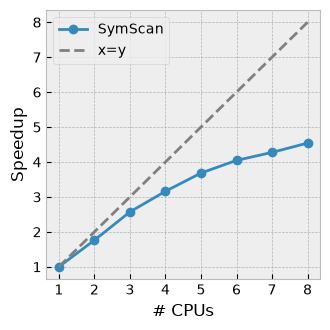

In [13]:
mean = ncpu_df.groupby('n_cpu')['runtime_s'].mean()
x, y = mean.index.values, mean.values
speedup = y[0] / y

fig, ax = plt.subplots(figsize=(3.4, 3.4))
ax.plot(x, speedup, 'o-', label='SymScan')
ax.plot(x, x, '--', color='gray', label='x=y')
ax.set_xticks(x)
ax.set_xlabel('# CPUs')
ax.set_ylabel('Speedup')
ax.legend()
fig.tight_layout()
fig.savefig('figs/symscan_ncpu_benchmark.svg')